# 06 · Head-to-head comparison & tuning

Now we put all four libraries on the **same data, same split** and compare:

- **Accuracy** (RMSE / R² for regression, AUC / accuracy for classification)
- **Speed** (fit time, predict time)
- **Agreement on the signal** - do all four agree the noise features are useless?
- A small **tuning sweep** to show how the trio responds to `n_estimators`.

In [1]:
import os, sys, warnings, time
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.precision", 4)
from utils import data as D
from utils import plotting as P
from sklearn.metrics import root_mean_squared_error, r2_score, roc_auc_score, accuracy_score


In [2]:
reg = pd.read_parquet("../data/regression.parquet")
yreg = reg.pop("target"); Xreg = reg
Xtr, Xte, ytr, yte = D.train_test_split_df(Xreg, yreg, test_size=0.25, seed=0)

clf = pd.read_parquet("../data/classification.parquet")
yclf = clf.pop("target"); Xclf = clf
Xtr_c, Xte_c, ytr_c, yte_c = D.train_test_split_df(Xclf, yclf, test_size=0.25, seed=0)
_, _, gt = D.make_dataset("regression", n_samples=4000, seed=42)
print("ready")

ready


## Regression: train all four with comparable settings

In [3]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool
from interpret.glassbox import ExplainableBoostingRegressor

N = 400
def timed_fit(model, fit_fn):
    t0 = time.perf_counter(); fit_fn(); return time.perf_counter() - t0

results, fitted = [], {}

# XGBoost
m = XGBRegressor(n_estimators=N, learning_rate=0.05, max_depth=4,
                 enable_categorical=True, random_state=0)
ft = timed_fit(m, lambda: m.fit(Xtr, ytr)); fitted["XGBoost"] = m

# LightGBM
ml = LGBMRegressor(n_estimators=N, learning_rate=0.05, num_leaves=31,
                   random_state=0, verbose=-1)
ftl = timed_fit(ml, lambda: ml.fit(Xtr, ytr)); fitted["LightGBM"] = ml

# CatBoost
mc = CatBoostRegressor(iterations=N, learning_rate=0.05, depth=4,
                       random_seed=0, verbose=0)
pool = Pool(Xtr, ytr, cat_features=["category"])
ftc = timed_fit(mc, lambda: mc.fit(pool)); fitted["CatBoost"] = mc

# EBM
me = ExplainableBoostingRegressor(interactions=5, learning_rate=0.02, random_state=0)
fte = timed_fit(me, lambda: me.fit(Xtr, ytr)); fitted["EBM"] = me

for name, fit_t in zip(fitted, [ft, ftl, ftc, fte]):
    mdl = fitted[name]
    Xpred = Xte
    t0 = time.perf_counter(); pred = mdl.predict(Xpred); pt = time.perf_counter() - t0
    results.append({"model": name,
                    "RMSE": root_mean_squared_error(yte, pred),
                    "R2": r2_score(yte, pred),
                    "fit_s": fit_t, "predict_s": pt})
res = pd.DataFrame(results).set_index("model")
res.round(4)

,RMSE,R2,fit_s,predict_s
model,,,,
XGBoost,2.0868,0.8495,2.7392,0.0058
LightGBM,1.6899,0.9013,2.6370,0.0054
CatBoost,1.6829,0.9021,17.9071,0.0018
EBM,1.2065,0.9497,11.2990,0.0010


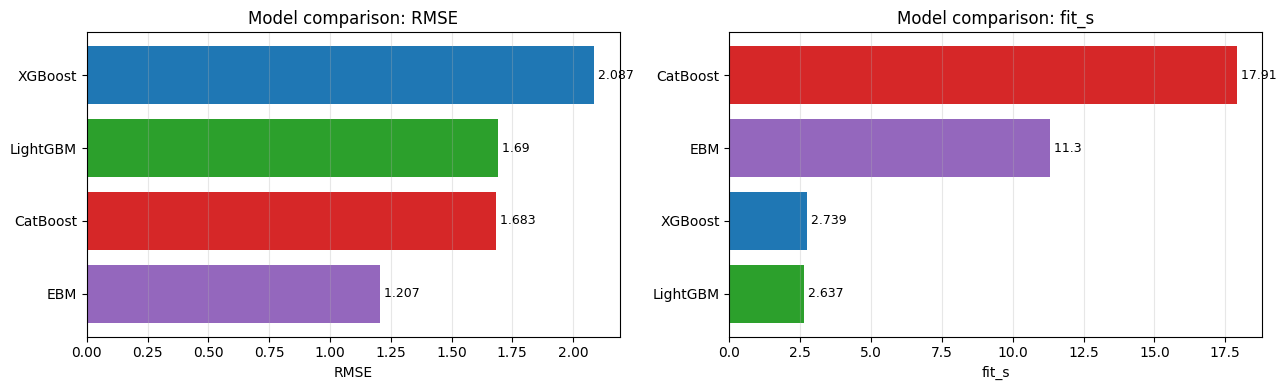

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
P.benchmark_bar(res, "RMSE", ax=axes[0], lower_is_better=True)
P.benchmark_bar(res, "fit_s", ax=axes[1], lower_is_better=True)
plt.tight_layout(); plt.show()

## Classification: AUC & accuracy

             AUC  accuracy
model                     
XGBoost   0.7858     0.709
LightGBM  0.7664     0.703
CatBoost  0.7946     0.712
EBM       0.7990     0.716


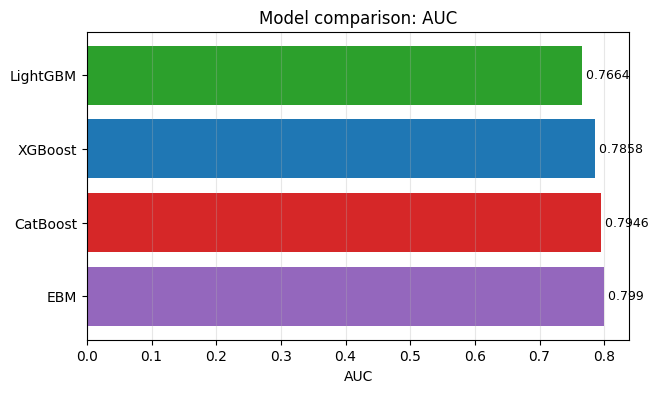

In [5]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

crows = []
xc = XGBClassifier(n_estimators=N, learning_rate=0.05, max_depth=4,
                   enable_categorical=True, random_state=0).fit(Xtr_c, ytr_c)
lc = LGBMClassifier(n_estimators=N, learning_rate=0.05, num_leaves=31,
                    random_state=0, verbose=-1).fit(Xtr_c, ytr_c)
cc = CatBoostClassifier(iterations=N, learning_rate=0.05, depth=4, verbose=0,
                        random_seed=0).fit(Pool(Xtr_c, ytr_c, cat_features=["category"]))
from interpret.glassbox import ExplainableBoostingClassifier
ec = ExplainableBoostingClassifier(interactions=5, random_state=0).fit(Xtr_c, ytr_c)

for name, mdl in [("XGBoost", xc), ("LightGBM", lc), ("CatBoost", cc), ("EBM", ec)]:
    proba = mdl.predict_proba(Xte_c)[:, 1]
    crows.append({"model": name,
                  "AUC": roc_auc_score(yte_c, proba),
                  "accuracy": accuracy_score(yte_c, (proba > 0.5).astype(int))})
cres = pd.DataFrame(crows).set_index("model")
print(cres.round(4))
P.benchmark_bar(cres, "AUC"); plt.show()

## Do all four agree on the signal?

The real test of trust: every model should rank the planted features high and
the **noise features (x6, x7, x8) near zero**. We normalise each model's
importances and stack them.

            true_role  XGBoost  LightGBM  CatBoost    EBM
x0             linear    0.296     0.107     0.270  0.287
x1             linear    0.149     0.101     0.146  0.189
x2             linear    0.108     0.108     0.085  0.141
x3        interaction    0.040     0.168     0.139  0.016
x4        interaction    0.040     0.168     0.134  0.010
x5          nonlinear    0.055     0.124     0.096  0.123
x6              noise    0.008     0.070     0.001  0.009
x7              noise    0.006     0.065     0.000  0.005
x8              noise    0.009     0.071     0.001  0.015
category  categorical    0.289     0.020     0.128  0.206


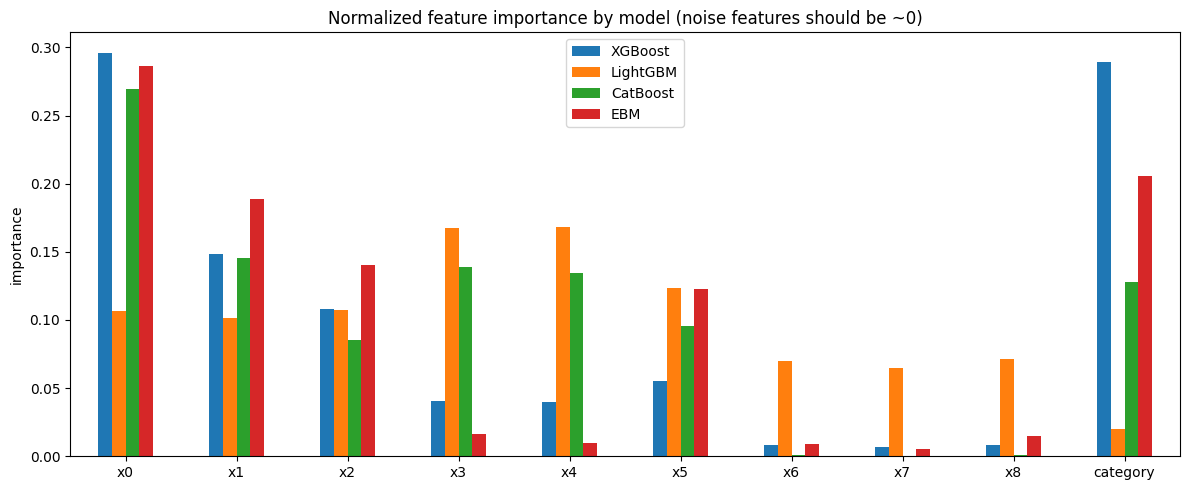

In [6]:
def norm_imp(d):
    s = sum(d.values()); return {k: v/s for k, v in d.items()} if s else d

imps = {
    "XGBoost":  norm_imp(dict(zip(Xreg.columns, fitted["XGBoost"].feature_importances_))),
    "LightGBM": norm_imp(dict(zip(Xreg.columns, fitted["LightGBM"].feature_importances_))),
    "CatBoost": norm_imp(dict(zip(Xreg.columns, fitted["CatBoost"].get_feature_importance(pool)))),
}
# EBM: main-effect importances only.
g = fitted["EBM"].explain_global().data()
ebm_main = {k: v for k, v in zip(g["names"], g["scores"]) if k in Xreg.columns}
imps["EBM"] = norm_imp(ebm_main)

table = pd.DataFrame(imps).reindex(D.NUMERIC_FEATURES + ["category"]).fillna(0)
roles = gt.describe().set_index("feature")["true_role"]
table.insert(0, "true_role", roles)
print(table.round(3))

ax = table.drop(columns="true_role").plot.bar(figsize=(12, 5))
ax.set(title="Normalized feature importance by model (noise features should be ~0)",
       ylabel="importance"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

In [7]:
# Concretely: how much importance does each model waste on noise?
noise_share = table.loc[gt.noise_features].drop(columns="true_role").sum()
print("Share of importance assigned to NOISE features (lower = better):")
print(noise_share.round(4))

Share of importance assigned to NOISE features (lower = better):
XGBoost     0.0229
LightGBM    0.2053
CatBoost    0.0020
EBM         0.0291
dtype: float64


## A quick tuning sweep: `n_estimators` vs validation error

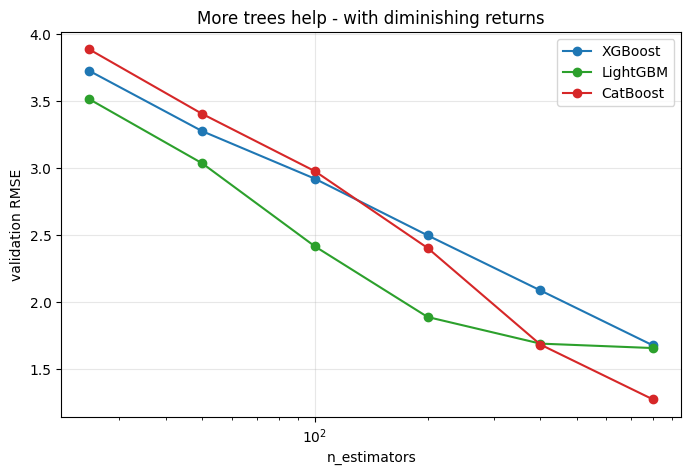

In [8]:
grid = [25, 50, 100, 200, 400, 800]
curves = {}
for nE in grid:
    xg = XGBRegressor(n_estimators=nE, learning_rate=0.05, max_depth=4,
                      enable_categorical=True, random_state=0).fit(Xtr, ytr)
    lg = LGBMRegressor(n_estimators=nE, learning_rate=0.05, num_leaves=31,
                       random_state=0, verbose=-1).fit(Xtr, ytr)
    cb = CatBoostRegressor(iterations=nE, learning_rate=0.05, depth=4, verbose=0,
                           random_seed=0).fit(pool)
    curves.setdefault("XGBoost", []).append(root_mean_squared_error(yte, xg.predict(Xte)))
    curves.setdefault("LightGBM", []).append(root_mean_squared_error(yte, lg.predict(Xte)))
    curves.setdefault("CatBoost", []).append(root_mean_squared_error(yte, cb.predict(Xte)))

fig, ax = plt.subplots(figsize=(8, 5))
for name, ys in curves.items():
    ax.plot(grid, ys, marker="o", label=name, color=P.MODEL_COLORS[name])
ax.set(xlabel="n_estimators", ylabel="validation RMSE", xscale="log",
       title="More trees help - with diminishing returns")
ax.legend(); ax.grid(alpha=0.3); plt.show()

## When to use which - a practical summary

| If you need… | Reach for |
|---|---|
| A strong, well-regularized default on numeric data | **XGBoost** |
| Maximum speed on large datasets | **LightGBM** |
| Best out-of-the-box on heavy categorical data | **CatBoost** |
| A model a human must be able to fully audit | **EBM** |

### Cross-cutting lessons from the series
- All gradient boosters share one engine: **fit the next tree to the current
  errors** (notebook 01). Everything else is engineering on top.
- **Early stopping + a small learning rate** is the most reliable recipe.
- On our planted data, all four recovered the true signal and assigned little
  importance to noise - but **EBM** let us *read the answer off directly* while
  the others needed SHAP.
- There's no universal winner: pick based on data shape, speed needs, and how
  much interpretability the use-case demands.